In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
df = pd.read_csv('Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [23]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [24]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [25]:
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()

ringkasan_outlier = []
for kolom in kolom_numerik:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    jumlah_outlier = df[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas)].shape[0]
    persen_outlier = round((jumlah_outlier / len(df)) * 100, 2)
    ringkasan_outlier.append([kolom, Q1, Q3, IQR, batas_bawah, batas_atas, jumlah_outlier, persen_outlier])

df_ringkasan_outlier = pd.DataFrame(
    ringkasan_outlier,
    columns=["Kolom", "Q1", "Q3", "IQR", "Batas_Bawah", "Batas_Atas", "Jumlah_Outlier", "Persen_Outlier"]
)

df_ringkasan_outlier

,Kolom,Q1,Q3,IQR,Batas_Bawah,Batas_Atas,Jumlah_Outlier,Persen_Outlier
0,price,3430000.0,5740000.0,2310000.0,-35000.0,9205000.0,15,2.75
1,area,3600.0,6360.0,2760.0,-540.0,10500.0,12,2.20
2,bedrooms,2.0,3.0,1.0,0.5,4.5,12,2.20
3,bathrooms,1.0,2.0,1.0,-0.5,3.5,1,0.18
4,stories,1.0,2.0,1.0,-0.5,3.5,41,7.52
5,parking,0.0,1.0,1.0,-1.5,2.5,12,2.20


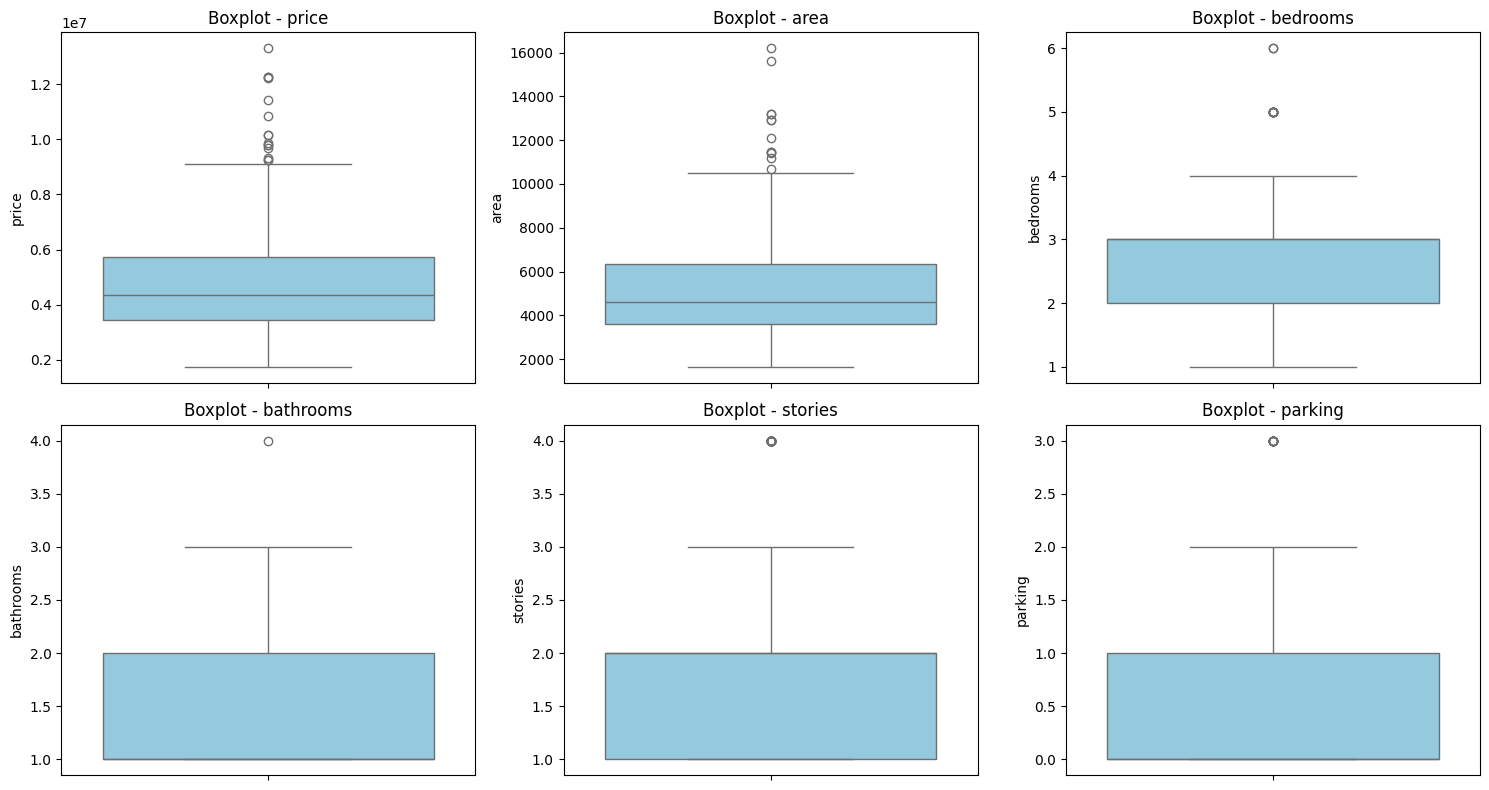

In [26]:
n_kolom = len(kolom_numerik)
n_baris_plot = int(np.ceil(n_kolom / 3))
fig, axes = plt.subplots(n_baris_plot, 3, figsize=(15, 4 * n_baris_plot))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    sns.boxplot(y=df[kolom], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot - {kolom}")

for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

In [27]:
df_encoded = df.copy()
kolom_object = df_encoded.select_dtypes(include=["object"]).columns.tolist()

encoder_mapping = {}
for kolom in kolom_object:
    le = LabelEncoder()
    df_encoded[kolom] = le.fit_transform(df_encoded[kolom])
    encoder_mapping[kolom] = dict(zip(le.classes_, le.transform(le.classes_)))

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


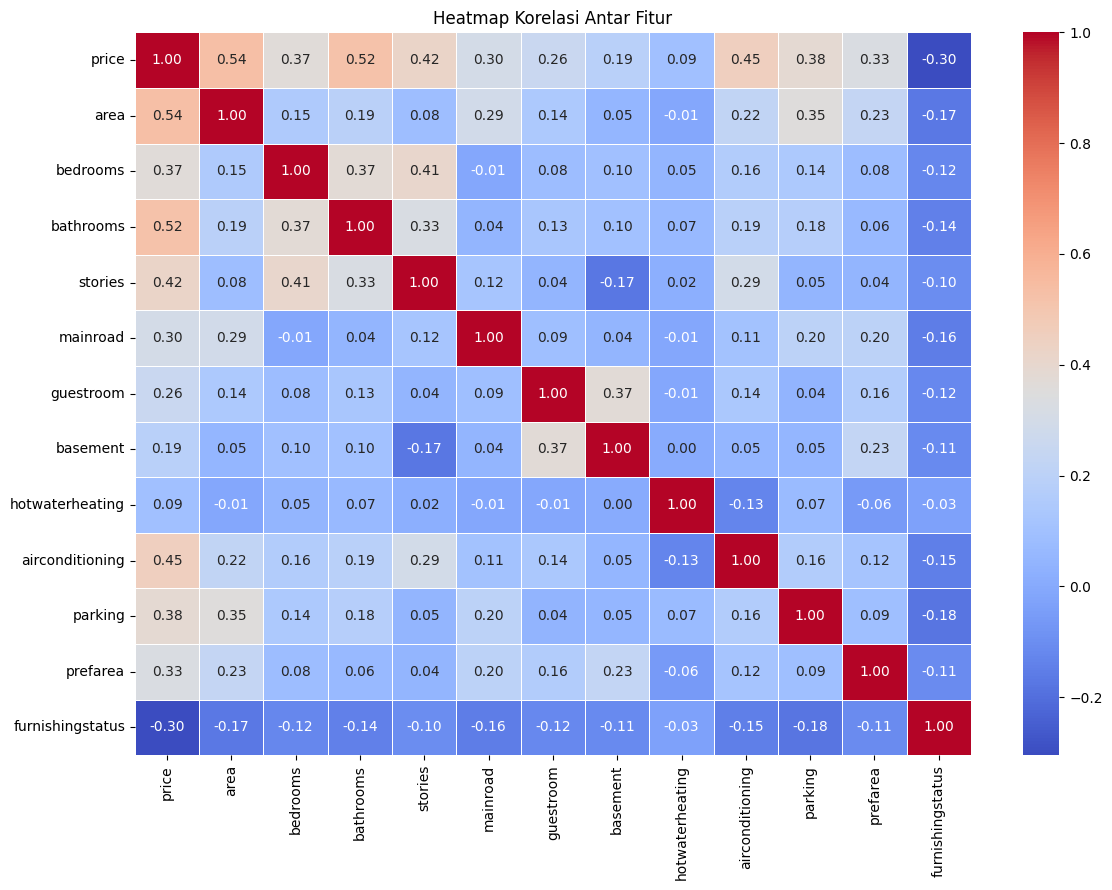

In [31]:
plt.figure(figsize=(12, 9))
matriks_korelasi = df_encoded.corr()
sns.heatmap(matriks_korelasi, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur")
plt.tight_layout()

In [34]:
df_encoded["price_category"] = pd.qcut(df_encoded["price"], q=3, labels=["Rendah", "Sedang", "Tinggi"])
print(df_encoded["price_category"].value_counts())

le_target = LabelEncoder()
df_encoded["price_category_enc"] = le_target.fit_transform(df_encoded["price_category"])
print(f"\nMapping kelas target: "
      f"{dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

price_category
Rendah    186
Tinggi    182
Sedang    177
Name: count, dtype: int64

Mapping kelas target: {'Rendah': np.int64(0), 'Sedang': np.int64(1), 'Tinggi': np.int64(2)}


In [36]:
fitur_kontinu = ["area", "bedrooms", "bathrooms", "stories", "parking"]
fitur_kategorik = ["mainroad", "guestroom", "basement", "hotwaterheating",
                    "airconditioning", "prefarea", "furnishingstatus"]
target = "price_category_enc"

X = df_encoded[fitur_kontinu + fitur_kategorik]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
parameter_fuzzy = {}
for kolom in fitur_kontinu:
    a = X_train[kolom].min()
    b = X_train[kolom].mean()
    c = X_train[kolom].max()
    parameter_fuzzy[kolom] = (a, b, c)

for kolom, (a, b, c) in parameter_fuzzy.items():
    print(f"{kolom}: a(min)={a:.2f}, b(mean)={b:.2f}, c(max)={c:.2f}")

himpunan_fuzzy = ["Rendah", "Sedang", "Tinggi"]

fuzzy_train = pd.DataFrame(index=X_train.index)
fuzzy_test = pd.DataFrame(index=X_test.index)

for kolom in fitur_kontinu:
    a, b, c = parameter_fuzzy[kolom]
    epsilon = 1e-9

    for data_x, fuzzy_out in [(X_train[kolom], fuzzy_train), (X_test[kolom], fuzzy_test)]:
        rendah = np.clip((b - data_x) / (b - a + epsilon), 0, 1)
        naik = (data_x - a) / (b - a + epsilon)
        turun = (c - data_x) / (c - b + epsilon)
        sedang = np.clip(np.minimum(naik, turun), 0, 1)
        tinggi = np.clip((data_x - b) / (c - b + epsilon), 0, 1)

        fuzzy_out[f"{kolom}_Rendah"] = rendah
        fuzzy_out[f"{kolom}_Sedang"] = sedang
        fuzzy_out[f"{kolom}_Tinggi"] = tinggi
        
fuzzy_train.head()

area: a(min)=1650.00, b(mean)=5143.04, c(max)=15600.00
bedrooms: a(min)=1.00, b(mean)=2.97, c(max)=6.00
bathrooms: a(min)=1.00, b(mean)=1.28, c(max)=4.00
stories: a(min)=1.00, b(mean)=1.81, c(max)=4.00
parking: a(min)=0.00, b(mean)=0.69, c(max)=3.00


,area_Rendah,area_Sedang,area_Tinggi,bedrooms_Rendah,bedrooms_Sedang,bedrooms_Tinggi,bathrooms_Rendah,bathrooms_Sedang,bathrooms_Tinggi,stories_Rendah,stories_Sedang,stories_Tinggi,parking_Rendah,parking_Sedang,parking_Tinggi
190,0.000000,0.765040,0.234960,0.000000,0.660106,0.339894,1.0,0.000000,0.000000,0.0,0.911181,0.088819,0.0,0.433831,0.566169
527,0.946751,0.053249,0.000000,0.492433,0.507567,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000
25,0.000000,0.866408,0.133592,0.000000,0.660106,0.339894,0.0,0.734625,0.265375,0.0,0.911181,0.088819,0.0,0.433831,0.566169
194,0.000000,0.712444,0.287556,0.000000,0.990159,0.009841,0.0,0.734625,0.265375,1.0,0.000000,0.000000,1.0,0.000000,0.000000
147,0.000000,0.965864,0.034136,0.000000,0.990159,0.009841,0.0,0.734625,0.265375,0.0,0.911181,0.088819,0.0,0.867662,0.132338


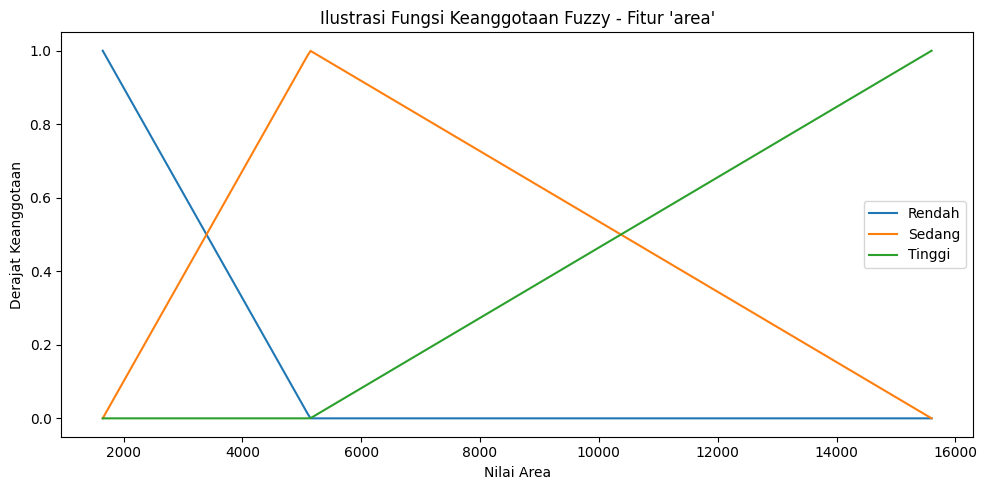

In [39]:
a, b, c = parameter_fuzzy["area"]
x_range = np.linspace(X_train["area"].min(), X_train["area"].max(), 300)
epsilon = 1e-9
rendah_plot = np.clip((b - x_range) / (b - a + epsilon), 0, 1)
sedang_plot = np.clip(np.minimum((x_range - a) / (b - a + epsilon), (c - x_range) / (c - b + epsilon)), 0, 1)
tinggi_plot = np.clip((x_range - b) / (c - b + epsilon), 0, 1)

plt.figure(figsize=(10, 5))
plt.plot(x_range, rendah_plot, label="Rendah", color="tab:blue")
plt.plot(x_range, sedang_plot, label="Sedang", color="tab:orange")
plt.plot(x_range, tinggi_plot, label="Tinggi", color="tab:green")
plt.title("Ilustrasi Fungsi Keanggotaan Fuzzy - Fitur 'area'")
plt.xlabel("Nilai Area")
plt.ylabel("Derajat Keanggotaan")
plt.legend()
plt.tight_layout()

In [44]:
daftar_kelas = sorted(y_train.unique())
jumlah_kelas = len(daftar_kelas)

# --- Prior P(kelas) ---
prior_kelas = {}
for kelas in daftar_kelas:
    prior_kelas[kelas] = (y_train == kelas).sum() / len(y_train)

print(prior_kelas)

prob_kategorik = {}
for kolom in fitur_kategorik:
    prob_kategorik[kolom] = {}
    nilai_unik = X_train[kolom].unique()
    for kelas in daftar_kelas:
        subset = X_train[kolom][y_train == kelas]
        prob_kategorik[kolom][kelas] = {}
        for nilai in nilai_unik:
            jumlah_nilai = (subset == nilai).sum()
            prob_kategorik[kolom][kelas][nilai] = (jumlah_nilai + 1) / (len(subset) + len(nilai_unik))

prob_fuzzy = {}
for kolom in fitur_kontinu:
    prob_fuzzy[kolom] = {}
    for kelas in daftar_kelas:
        idx_kelas = y_train[y_train == kelas].index
        prob_fuzzy[kolom][kelas] = {}
        for himpunan in himpunan_fuzzy:
            kolom_fuzzy = f"{kolom}_{himpunan}"
            prob_fuzzy[kolom][kelas][himpunan] = fuzzy_train.loc[idx_kelas, kolom_fuzzy].mean() + 1e-9

print("\nContoh tabel probabilitas fuzzy untuk fitur 'area':")
pd.DataFrame(prob_fuzzy["area"])

{np.int64(0): np.float64(0.34174311926605505), np.int64(1): np.float64(0.32339449541284404), np.int64(2): np.float64(0.3348623853211009)}

Contoh tabel probabilitas fuzzy untuk fitur 'area':


,0,1,2
Rendah,0.395813,0.252292,0.056232
Sedang,0.578383,0.683888,0.796630
Tinggi,0.025804,0.063820,0.147138


In [ ]:
prediksi = []
for i in X_test.index:
    skor_kelas = {}
    for kelas in daftar_kelas:
        skor = prior_kelas[kelas]

        for kolom in fitur_kategorik:
            nilai = X_test.loc[i, kolom]
            if nilai in prob_kategorik[kolom][kelas]:
                skor *= prob_kategorik[kolom][kelas][nilai]
            else:
                skor *= 1e-9

        for kolom in fitur_kontinu:
            kontribusi_fuzzy = 0
            for himpunan in himpunan_fuzzy:
                membership_x = fuzzy_test.loc[i, f"{kolom}_{himpunan}"]
                kontribusi_fuzzy += membership_x * prob_fuzzy[kolom][kelas][himpunan]
            skor *= kontribusi_fuzzy

        skor_kelas[kelas] = skor

    kelas_prediksi = max(skor_kelas, key=skor_kelas.get)
    prediksi.append(kelas_prediksi)

y_pred = pd.Series(prediksi, index=X_test.index)


Classification Report:
              precision    recall  f1-score   support

      Rendah       0.80      0.76      0.78        37
      Sedang       0.64      0.64      0.64        36
      Tinggi       0.79      0.83      0.81        36

    accuracy                           0.74       109
   macro avg       0.74      0.74      0.74       109
weighted avg       0.74      0.74      0.74       109


Confusion Matrix:
        Rendah  Sedang  Tinggi
Rendah      28       8       1
Sedang       6      23       7
Tinggi       1       5      30


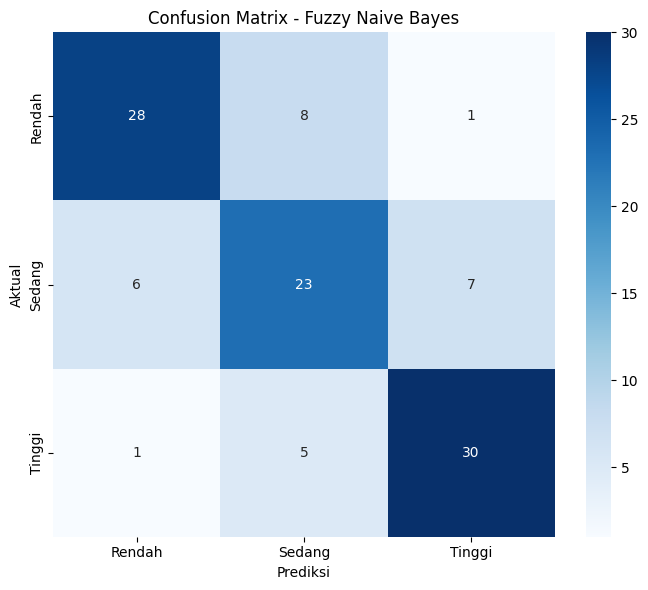

In [47]:
akurasi = accuracy_score(y_test, y_pred)
label_nama = le_target.classes_

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_nama))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=label_nama, columns=label_nama))

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_nama, yticklabels=label_nama)
plt.title("Confusion Matrix - Fuzzy Naive Bayes")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()

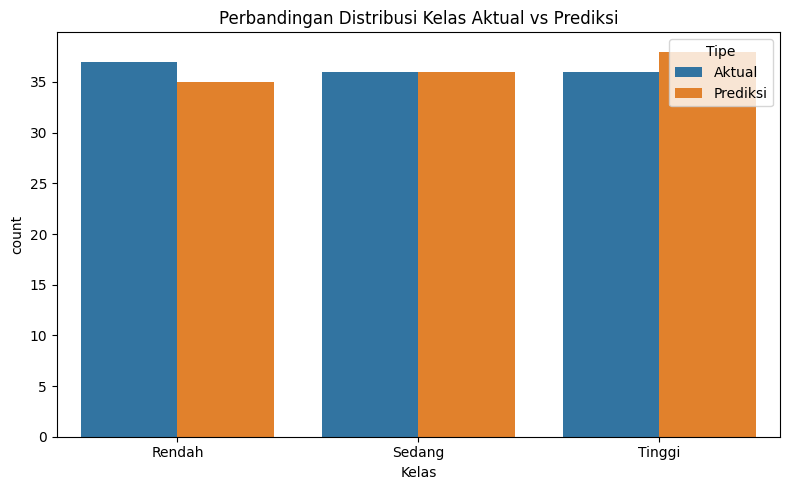

In [48]:
hasil_perbandingan = pd.DataFrame({"Aktual": y_test.map(dict(enumerate(label_nama))),
                                    "Prediksi": y_pred.map(dict(enumerate(label_nama)))})
plt.figure(figsize=(8, 5))
sns.countplot(data=hasil_perbandingan.melt(var_name="Tipe", value_name="Kelas"),
              x="Kelas", hue="Tipe", order=label_nama)
plt.title("Perbandingan Distribusi Kelas Aktual vs Prediksi")
plt.tight_layout()